DCGAN: DEEP CONVOLUTIONAL GENERATIVE ADVERSARIAL NETWORKS

La reti densi trattano i pixel come una lista della spesa, senza capire che un pixel sopra un'altro forma un bordo. 
Con le DCGAN si introduce la geometria della convoluzioni, si insegna alle macchine non solo a copiare dei valore ma comprendere la prospettiva, le ombre e la geometria del mondo.

- Linea guida architeturali: dal MLP alla Convoluzione
- Connvoluzione Trasposte: strumento che permette al generatore di far fiorire un immagine partendo da un piccolo seme.
- Inizializzazione dei Pesi e Stabilità del gradiente. il modo in cui si inizia è importante

Le DCGAN rappresentano l'evoluzione delle GAN classiche, introducendo i layer convoluzionali per catturare la gerarchia spaziale delle immagini.
Proposte da Radfor  nel 2015, queste reti segueno regole precise per stabilizzare il training avversario, che è intrinsecamente instabile nella GAN.
Le GN originali non sapevano gestire immagini complesse, ma non servivano solo poiù neuroni ma una gerarchia spaziale. Riconosce linee, forme e bordi, le DCGAN catturano questa progressione.
Passaggio fondamentale per passare da un visione puntiforme (pixel) ad una visione strutturata del mondo.

Per far funzionare questo sistema però, abbiamo dovuto buttar via quasi tutto quello che sapevamo sulle reti neurali classiche.

Le 4 regole d'oro di RadFord
1) Sostituzione dei layer di Pooling con Strided Convolutions del Discriminatore e Fractional-strided Convolutions del Generatore. Perchè il Pooling è stato eliminato e vogliamo che la rete impari da sola come ridurre o aumentare la risoluzione.
2) Uso della 'batch normalization' in entrambi i modelli per stabilizzare l'apprendimento e prevenire il mode collapse. 
3) Rimozione dei layer Fully Connected (Dense) a favore di architetture interamente convoluzionali profonde
4) Utilizzo di ReLU nel Generatore (tranne l'output) e LeakyReLU nel Discriminatore per mantenere attivi i gradienti

Perchè eliminare il Pooling?
Le strided convolutions permettono alla rete di imparare autonomamente come ridurre la risoluzione, invece di usare funzioni fisse come il Max Pooling (apprendimento del Downsampling).
Normalizzando le attivazioni per avere media zero e varianza unitaria, si mitigano i problemi derivanti da una cattiva inizializzazione (batch normalization) in modo che nessuna rete prenda il sopravvento sull'altra troppo in fretta.
L'inclinazione alpha (solitamente 0.2) evita che il discriminatore smetta di imparare quando i neuroni sono disattivati (LeakyReLU)

Ruolo Vitale della Batch Normalization
Senza normalizzazione, i gradienti tendono a oscillare o a svanire a causa della natura dinamica del gioco min-max. E' come cerca di camminare su una fune durante un terremoto, i gradienti tendono ad oscillare.
La Batch Norm forza i dati a restare in un range dove le funzioni di attivazione sono più sensibili, facilitando la cooperazione tra G e D. 
E' il collante che tiene insieme l'intera architettura.

Le DCGAN sono il passo naturale dopo le GAN.
Il concetto di GAN non cambia: c'è Generatore e Discriminatore che competono. Cambia il modo in cui trattano le immagini.
GAN:
G: noise -> linear -> linear -> 784 pixel
D: immagine -> 784 valori -> linear -> linear -> real/fake
DCGAN:
G: noise -> rappresentazione spaziale -> ConvTranspose2d -> ConTranspose2d ->immagine
D: immagine -> Conv2d -> Conv2d -> real/fake

La rete non tratta più l'immagine semplicemente come 784 numeri indipendneti.
La DCGAN, impare anche rappresentazioni spaziali usando layer convoluzionali

** DISCRIMINATORE **
con la GAN avevo: immagine 28x28 -> flatten -> 784 -> 512 -> 256 -> 1
con la DCGAN: immagine 28x28 -> conv2d -> 14x14 -> conv2d -> 7x7 -> ... -> real/fake
Quind il discriminatore diventa una CNN di classificazione binaria

Il Conv2d utilizza piccoli filtri (es 3x3) imparando complessità sempre maggiori esempio parte dai pixel ed impara i bordi, poi le curve, le forme, parti di immagine, struttura complessa.

** GENERATORE **
Qui la situazione è opposta rispetto al Discriminatore
Il Discriminatore fa: immagine grande -> rappresentazione piccola
Il generatore fa: rappresentazione piccola -> immagine grande
ed entra in gioco il ConvTranspose2d
Il Generatore deve compiere l'operazione inversa rispetto a un classificatore: deve passare da un piccolo vettore dens di 100 numeri casuali (il suo spazio latente) a un'immagine ad alta risoluzione.
Non è un semplice ingrandimento digitale, è l'operazione inversa rispetto a un classificatore.
La convoluzione normale riassume l'immagine, la trasposta la spalma e la espande, creando dettagli dove prima cera solo un idea astratta.
Questo processo avviene tramite le Convoluzione Trasposte (spesso chiamate Deconvoluzioni), che permettono di 'spalrmare' l'informazione su aree più vaste.

Con la Conv2d da immagine 64x64 arrivi ad immagine 32x32 (esempio)
Con il ConvTranspose2d fai il contrario, da immagine piccola a immagine grande.
4x4 -> 8x8  16x16 -> 32x32 -> 64x64
Come per le GAN classiche anche per DCGAN il generatore parte da rumore, mentre nella GAN avevamo la fomra [batch,rumore] nella DCGAN [batch, canali, altezza, larghezza]
Esempio
[64,100,1,1]
64=batch 100=spazio latente 1=altezza 1=larghezza
il rumero diventa pertanto una piccola immagine 1x1 con 100 feature
Un esempio classico:
z= 100x1x1 -> ConvTranspose -> 512x4x4 -> ConvTranspose -> 256x8x8x -> ConvTranspose -> 125x16x16 -> ConvTranspose -> 64x332x32 -> ConvTranspose -> 3x64x64
L'ultimo layer sono 3 cancali RGB per MNIST  sarebbe invece 1 canale

Ma come funzione questo processo di creazione di pixel?
Come creare risoluzione dal rumore.
- La convoluzione trasposta proietta un singolo valore di input su una matrice di output tramite un kernel apprendibile
- Lo 'stride' in questo contesto non salta pixel in input, ma distanzia i risultati in output aumentando la dimensione spaziale.
- A differenza dell'interpolazione classica (bilineare), qui la rete impara i pesi ottimali per ricostruire i dettagli fini. E' come se la rete inventasse i pixel mancanti basandosi sulla coerenza globale.
- Questo operazione è fondamentale per passare dalla dimensione latente 1x1 alla dimensione finale dell'immagine (es. 28x28 o 64x64)

Nella pratica usiamo kernel di dimensione 4x4 o 5x5 è lo standard per evitare artefatti a scacchiera (checkerboard artifacts) durante l'espansione.
Il numero di filtri diminuisce man mano che l'immagine ingrandisce. Iniziamo con 512 filtri, per capire la struttura macroscopica, e finiamo con solo 3 filtri per colore RGB. Il padding poi non ci serve per proteggere i bordi ma per controllare che la dimensione finale sia esattamente quella del dataset reale.
Se questo pennello virtuale non è ben calibrato, rischiamo di creare degli artefatti visivi.

Upsampling e Artefatti.
La sfida della nitidezza
Hai mai visto, nelle immmagini generate, una trama a schacchiera sovrapposta? Quelli accadono quando lo stride ed il kernel non sono più in armonia e la rete rinisce per dipingere zone più volte rispeetto ad altre.
Le convoluzioni trasposte possono generare pattern ripetitivi non desiderati se i parametri di stride e kernel non sono bilanciati correttamente.
Nelle DCGAN moderne, si preferisce usare kernel che siano multipli esatti dello stride per garantie una copertura uniforme dell'output
Con stride 2 il kernel dovrebbe essere 4 o 6, questo garantisce una copertura uniforme ed un'immagine finale nitida e naturale, senza effetto digitale che tradirebbe la natura sintetica delle immagini.

Ora dobbiamo decidere come far iniziare il battito della rete

Inizializzazione dei Peesi
L'inizializzazione è importante nella GAN è una questione di vita o di morte.
Se partiamo con pesi troppo grandi, il discriminatore darà giudizi estremi uccidendo il gradiente.
Se partiamo con pesi troppo piccoli, la rete non avrà mai la forza di uscire dalla situazione iniziale
In una rete profonda come la DCGAN, il modo in cui inizializziamo i parametri determina se il gradiente riuscirà a fluire attraverso tutti i layer.
Radford suggerisce di evitare l'inizializazione standard a favore di una distribuzione normale con parametri specifici per prevenire esplosioni o sparizioni del gradiente.

Vediamo i numeri precisi di questa taratura iniziale.

Distribuzione Normale Curate
Calibrare l'inizio del duello
- Tutti i pesi devono essere inizializzati da una distribuzione normale con media zero e deviazione standard molto piccola pari a 0.02 (regola d'oro). Queta varianza ridotta mantiene le attivazioni in una zona di sensibiità massima. non vogliamo che la rete sia sicura di nulla all'inizio, vogliamo che sia in uno stato di incertezza creativa.
- Questa varianza ridotta impedisce alle funzioni di attivazione di saturare immediatamente, mantenendo la rete reattiva.
- I bias vengono solitamente inizializzati a zero per non introdurre asimmetrie ingiustificate nella fasi iniziali.
- Un'inizializzazione correta è spesso l'unica differenza tra un modello che collassa e uno che genera volti realistici.

Questa scelta influenza anche il modo con cui inizializzeremo i nostri ottimizzatori.
Inizializzare bene permette di usare ottimizzatori come Adam con un momentum (beta1) ridotto a 0.5 per una maggiore stabilità. Questo rende il movimento tra i pesi più leggero e reattivo.
Se i pesi sono troppo grandi, la sigmoide del discriminatore datà subito 0 o 1, uccidendo il gradiente per il generatore (saturazione precoce).
Mantenere la stessa varianza tra i layer assicura che il segnale non si amplifichi o si attenui eccessivamente durante la barckpropagation (durate il viaggio di ritorno).

Mentre la risoluzione spaziale aumenta, il numero di feature maps diminuisce. All'inizio hai molte feature astrate e poca informazione spaziale, alla fine hai pochi cancali e moltissima informazione spaziale.
Il Generatore stra progressivamente trasformando una rappresentazione astratta in pixel.

All'inizio il lantent vector potrebbe contenere informazioni come: forma generale, dimensione, stile, texture, posizione
Non significa che possiamo associare z[12]=colore e z[32]=rotazione
ma la rete costruisce una rappresentazione distribuita.
Durante l'unsampling:
latent vector -> struttura globale -> forma dell'oggetto -> parti -> texture -> dettagli -> pixel

Il Discriminatore fa esattamente il contrario
Esempio
3x64x64 -> Conv2d -> 64x32x32 -> Conv2d -> 128x16x16 -> Conv2d -> 256x8x8 -> Conv2d -> 512x4x4 -> 1

Quindi:
GENERATOR
astratto -> concreto
DISCRIMINATOR
concreto -> astratto

Implementazione in PyTorch
La funzione weights_init
In PyThorc non dobbiamo impostare i pesi a mano layer per layer.
In PyTorch, definiamo solitamente una funzione helper (chiamata weights_init) che agisce come un supervisore che attraversa ricorsivamente tutti i moduli 'Conv' e 'BatchNorm' (attraversa l'intera rete) per applicare queste regole.
model.apply(weights_init)
Questo garantisce che l'intera architettura parta da uno stato di equilibrio statistico ideale per iniziare la competizione, quindi garantiamo che l'architettura sia equilibrata ancora prima che la prima immagine venga caricata.

Inizio addestramento DCGAN su cpu...
Epoca [1/15] | Loss_D: 0.5296 | Loss_G: 1.6548
Epoca [2/15] | Loss_D: 0.8124 | Loss_G: 2.9398
Epoca [3/15] | Loss_D: 0.8063 | Loss_G: 1.9778
Epoca [4/15] | Loss_D: 0.9025 | Loss_G: 2.1756
Epoca [5/15] | Loss_D: 0.8645 | Loss_G: 1.7246
Epoca [6/15] | Loss_D: 0.9730 | Loss_G: 1.1239
Epoca [7/15] | Loss_D: 0.8798 | Loss_G: 1.4943
Epoca [8/15] | Loss_D: 1.3627 | Loss_G: 2.2058
Epoca [9/15] | Loss_D: 0.8608 | Loss_G: 1.6082
Epoca [10/15] | Loss_D: 1.0024 | Loss_G: 1.7850
Epoca [11/15] | Loss_D: 1.0154 | Loss_G: 1.4012
Epoca [12/15] | Loss_D: 1.1321 | Loss_G: 1.9010
Epoca [13/15] | Loss_D: 0.9869 | Loss_G: 1.4700
Epoca [14/15] | Loss_D: 1.0275 | Loss_G: 1.5801
Epoca [15/15] | Loss_D: 1.1506 | Loss_G: 2.0047


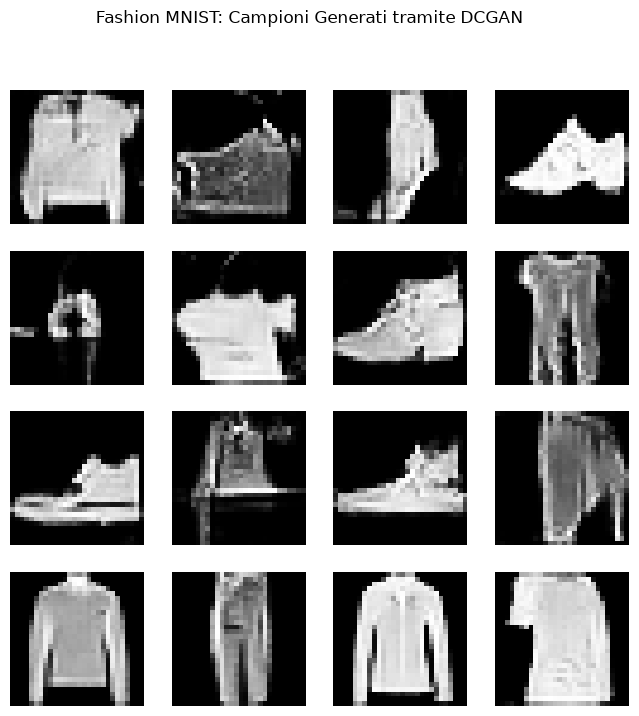

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. CONFIGURAZIONE E IPERPARAMETRI
# -------------------------------------------------------------------------
# Selezione del dispositivo di calcolo: GPU se disponibile, altrimenti CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dimensione del vettore di rumore casuale (spazio latente) in ingresso al generatore.
latent_dim = 100

# Parametri di ottimizzazione standard per DCGAN (Deep Convolutional GAN).
# Un tasso di apprendimento di 0.0002 e un beta1 di 0.5 sono consigliati per la stabilita'.
lr = 0.0002
beta1 = 0.5 
batch_size = 128
epochs = 15

# Trasformazioni per il dataset:
# 1. ToTensor: Converte l'immagine PIL in un tensore PyTorch [0, 1].
# 2. Normalize: Sposta i valori nel range [-1, 1]. Questo e' fondamentale perche' 
# lo strato finale del Generatore usa una funzione Tanh che produce valori tra -1 e 1.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Caricamento del dataset FashionMNIST.
# Viene scaricato localmente e preparato per il caricamento a blocchi (batch).
train_loader = DataLoader(
    datasets.FashionMNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

# -------------------------------------------------------------------------
# 2. INIZIALIZZAZIONE DEI PESI
# -------------------------------------------------------------------------
# Per le architetture DCGAN, gli autori suggeriscono di inizializzare i pesi 
# seguendo una distribuzione normale con media 0 e deviazione standard 0.02.
# Questo aiuta a prevenire la saturazione delle funzioni di attivazione e 
# rende l'inizio dell'addestramento piu' fluido.
def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname: #layer convoluzionali
        # Pesi delle convoluzioni inizializzati intorno allo zero.
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname: #layer batch normalization
        # BatchNorm inizializzato con media 1 e deviazione standard 0.02.
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# -------------------------------------------------------------------------
# 3. ARCHITETTURA: GENERATORE
# -------------------------------------------------------------------------
# Il compito della classe Generator e' trasformare un vettore di rumore (spazio latente)
# in un'immagine che sembri reale (28x28 pixel, in scala di grigi).
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # Utilizziamo ConvTranspose2d (convoluzioni trasposte o de-convoluzioni) 
        # per "espandere" il vettore piatto iniziale in una griglia spaziale.
        self.main = nn.Sequential(
            # Input: (100) x 1 x 1 -> Trasformato in 256 mappe di caratteristiche 7x7.
            # input [128,100,1,1] output [128,256,7,7] genera quindi 256 feature map ognunga 7x7
            nn.ConvTranspose2d(latent_dim, 256, 7, 1, 0, bias=False), #aumenta la risoluzione spaziale
            nn.BatchNorm2d(256), # Stabilizza l'apprendimento normalizzando le attivazioni.
            nn.ReLU(True),       # ReLU e' l'attivazione standard per gli strati intermedi del Generatore.
            
            # Espansione: 256 x 7 x 7 -> 128 x 14 x 14. 
            # La risoluzione raddoppia il numero di feature map diminuisce
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            # Output finale: 128 x 14 x 14 -> 1 x 28 x 28 (dimensione FashionMNIST).
            # dimensione 1 perchè MNIST è grayscale, in un'immagine RGB avresti 3xHxW, qui hai1x28x28
            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),
            nn.Tanh() # Restituisce valori in [-1, 1] per matchare la normalizzazione dei dati.
        )
    
    def forward(self, x):
        # Il flusso dei dati riceve il rumore e lo passa attraverso la sequenza definita sopra.
        return self.main(x)

# -------------------------------------------------------------------------
# 4. ARCHITETTURA: DISCRIMINATORE
# -------------------------------------------------------------------------
# Il Discriminatore e' un classificatore binario che deve distinguere tra immagini
# reali (provenienti dal dataset) e immagini fake (create dal Generatore).
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        # Al contrario del Generatore, usiamo Convoluzioni standard per ridurre i dati spaziali
        # in un singolo valore di probabilita'.
        self.main = nn.Sequential(
            # Input: 1 x 28 x 28 (Immagine) -> 128 x 14 x 14.
            nn.Conv2d(1, 128, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True), # LeakyReLU aiuta a evitare gradienti nulli nel Discriminatore.
            
            # Riduzione ulteriore: 128 x 14 x 14 -> 256 x 7 x 7.
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Output finale: 256 x 7 x 7 -> 1 x 1 x 1 (Probabilita').
            nn.Conv2d(256, 1, 7, 1, 0, bias=False),
            nn.Sigmoid() # Restituisce un valore tra 0 (Fake) e 1 (Real).
        )
    
    def forward(self, x):
        # Elabora l'immagine e restituisce un valore piatto (squeezed) per il calcolo della loss.
        return self.main(x).view(-1, 1)

# Istanza dei modelli e spostamento sulla memoria del dispositivo (GPU/CPU).
netG = Generator().to(device)
netD = Discriminator().to(device)

# Applicazione del metodo di inizializzazione dei pesi definito al punto 2.
netG.apply(weights_init)
netD.apply(weights_init)

# Definizione dei due ottimizzatori separati, uno per ogni rete.
# Anche se lavorano insieme, le reti hanno obiettivi opposti e devono aggiornare i pesi in modo indipendente.
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# Binary Cross Entropy Loss: funzione di errore standard per compiti di classificazione binaria.
criterion = nn.BCELoss()

# -------------------------------------------------------------------------
# 5. CICLO DI ADDESTRAMENTO AVVERSARIALE
# -------------------------------------------------------------------------
# In questa fase le due reti interagiscono in un gioco "min-max": il Discriminatore 
# cerca di massimizzare la precisione, mentre il Generatore cerca di ingannarlo.

print(f"Inizio addestramento DCGAN su {device}...")

for epoch in range(epochs):
    for i, (real_images, _) in enumerate(train_loader):
        b_size = real_images.size(0)
        real_images = real_images.to(device)

        # -----------------------------------------------------------------
        # (A) AGGIORNAMENTO DEL DISCRIMINATORE
        # Obiettivo: Massimizzare log(D(x)) + log(1 - D(G(z)))
        # -----------------------------------------------------------------
        netD.zero_grad()
        
        # 1. Fase immagini reali: usiamo label 0.9 invece di 1.0 (Label Smoothing).
        # Questa tecnica aiuta a prevenire che il Discriminatore diventi troppo "sicuro"
        # e domini il Generatore rendendo i gradienti troppo deboli.
        label_real = torch.full((b_size, 1), 0.9, device=device)
        output_real = netD(real_images)
        lossD_real = criterion(output_real, label_real)
        
        # 2. Fase immagini fake: creiamo rumore e lo passiamo al Generatore.
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        fake_images = netG(noise)
        label_fake = torch.zeros(b_size, 1, device=device)
        
        # Passiamo le immagini fake a D. Usiamo .detach() perche' in questa fase
        # vogliamo solo aggiornare D, quindi non serve calcolare i gradienti per G.
        output_fake = netD(fake_images.detach())
        lossD_fake = criterion(output_fake, label_fake)
        
        # Unione delle perdite ed esecuzione della backpropagation.
        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # -----------------------------------------------------------------
        # (B) AGGIORNAMENTO DEL GENERATORE
        # Obiettivo: Massimizzare log(D(G(z))) -> Far credere a D che l'immagine sia reale.
        # -----------------------------------------------------------------
        netG.zero_grad()
        
        # Ripassiamo le immagini fake appena create a D, ma questa volta senza detach.
        # In questo modo, i gradienti fluiranno attraverso D fino a G.
        output_g = netD(fake_images)
        
        # Per il Generatore, l'errore si calcola basandosi su quanto D si sbaglia.
        # Puntiamo alla label "reale" (0.9) per spronare G a migliorare la qualità dei dettagli.
        lossG = criterion(output_g, label_real)
        
        lossG.backward()
        optimizerG.step()

    # Log dei progressi alla fine di ogni epoca.
    print(f"Epoca [{epoch+1}/{epochs}] | Loss_D: {lossD.item():.4f} | Loss_G: {lossG.item():.4f}")

# -------------------------------------------------------------------------
# 6. GENERAZIONE E VISUALIZZAZIONE DEI RISULTATI
# -------------------------------------------------------------------------
# Dopo l'addestramento, utilizziamo il Generatore per creare campioni di test 
# partendo da un rumore fisso per vedere i progressi qualitativi.
with torch.no_grad():
    fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)
    fake_samples = netG(fixed_noise).cpu()

# Creazione di una griglia 4x4 per mostrare gli abiti/scarpe generati dal modello.
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    # Mostriamo solo la prima dimensione (canale grigio) del tensore (1, 28, 28).
    plt.imshow(fake_samples[i][0], cmap='gray')
    plt.axis('off')

plt.suptitle("Fashion MNIST: Campioni Generati tramite DCGAN")
plt.show()